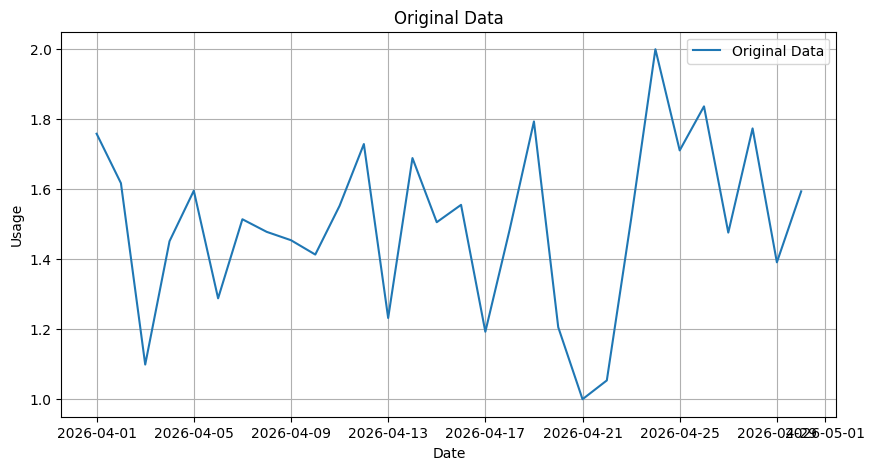

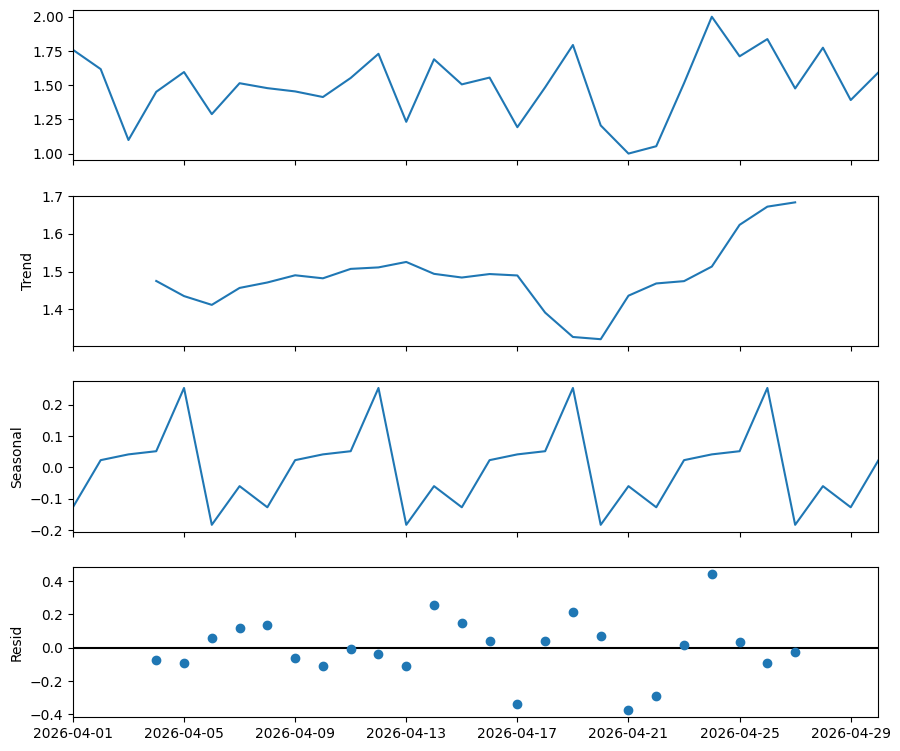

c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


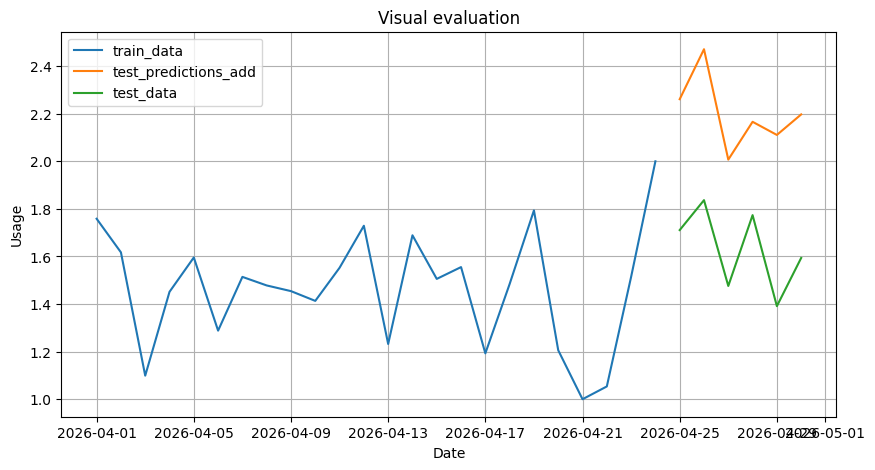

RMSE = 0.5806055414280645


c:\PROJECT\TSA\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


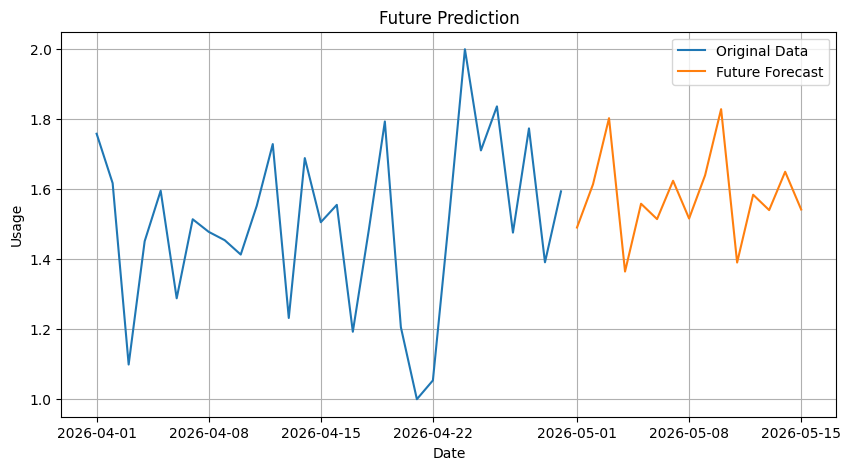

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose


data = pd.read_csv("user_behavior_timeseries.csv")

data.columns = data.columns.str.strip()


data['Date'] = pd.to_datetime(data['Date'])


data.set_index('Date', inplace=True)


daily_data = data.groupby('Date').mean(numeric_only=True)


col = "App Usage Time"


np.random.seed(10)

daily_data[col] = (
    daily_data[col]
    + np.random.normal(0, 2, len(daily_data))
)


scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    daily_data[[col]]
)

scaled_series = pd.Series(
    scaled.flatten(),
    index=daily_data.index
)


scaled_series = scaled_series + 1


plt.figure(figsize=(10,5))

plt.plot(
    scaled_series,
    label='Original Data'
)

plt.title("Original Data")
plt.xlabel("Date")
plt.ylabel("Usage")

plt.legend()
plt.grid(True)

plt.show()


decomposition = seasonal_decompose(
    scaled_series,
    model='additive',
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(10,8)

plt.show()


train_size = int(len(scaled_series) * 0.8)

train_data = scaled_series[:train_size]

test_data = scaled_series[train_size:]


model = ExponentialSmoothing(
    train_data,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()


test_predictions = model.forecast(
    steps=len(test_data)
)

plt.figure(figsize=(10,5))

plt.plot(
    train_data,
    label='train_data'
)

plt.plot(
    test_predictions,
    label='test_predictions_add'
)

plt.plot(
    test_data,
    label='test_data'
)

plt.legend()

plt.title("Visual evaluation")

plt.xlabel("Date")
plt.ylabel("Usage")

plt.grid(True)

plt.show()


rmse = np.sqrt(
    mean_squared_error(
        test_data,
        test_predictions
    )
)

print("RMSE =", rmse)


final_model = ExponentialSmoothing(
    scaled_series,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()


future_predictions = final_model.forecast(15)


plt.figure(figsize=(10,5))

plt.plot(
    scaled_series,
    label='Original Data'
)

plt.plot(
    future_predictions,
    label='Future Forecast'
)

plt.legend()

plt.title("Future Prediction")

plt.xlabel("Date")
plt.ylabel("Usage")

plt.grid(True)

plt.show()